# Import all kind of stuff

In [2]:
import numpy as np

from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic(
        "config", "InlineBackend.rc = {'figure.dpi': 300}"
    )  # choose a value you like

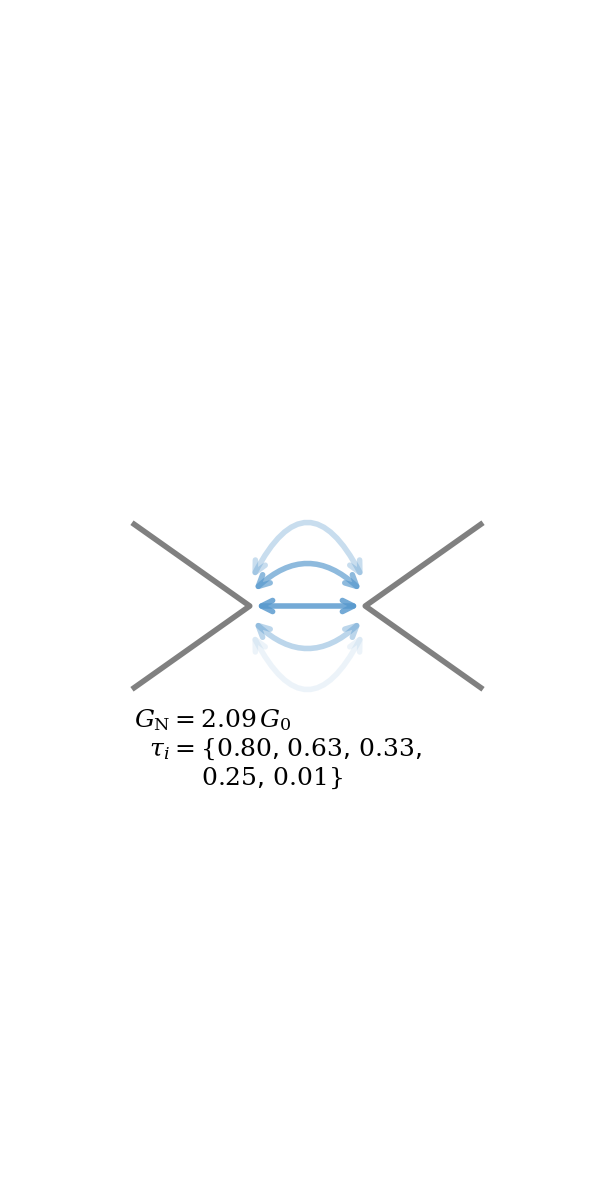

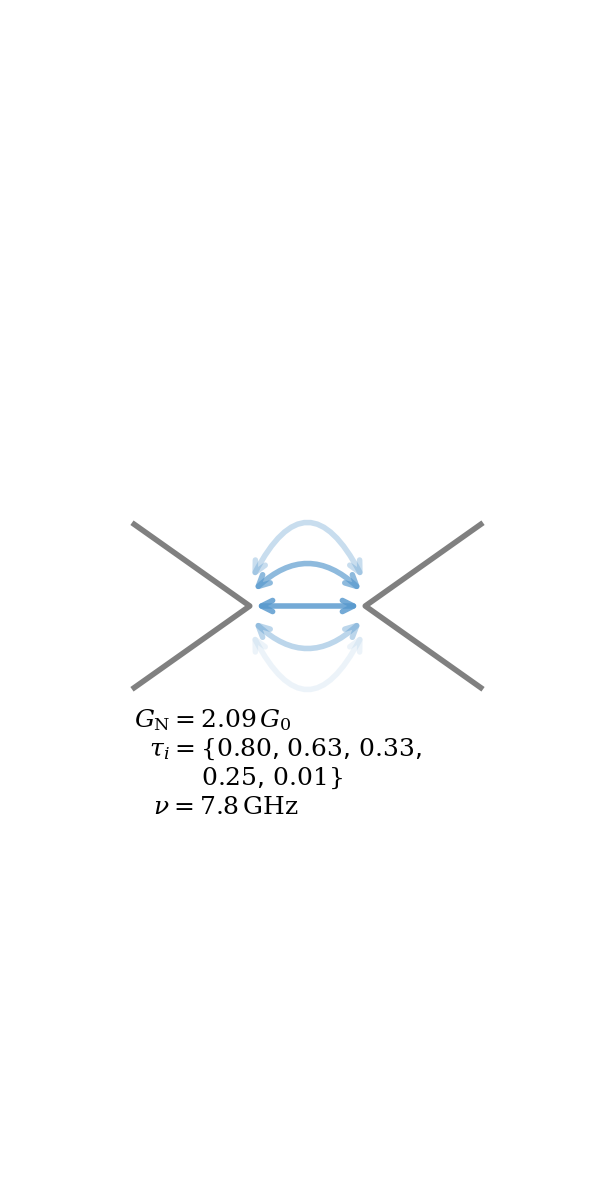

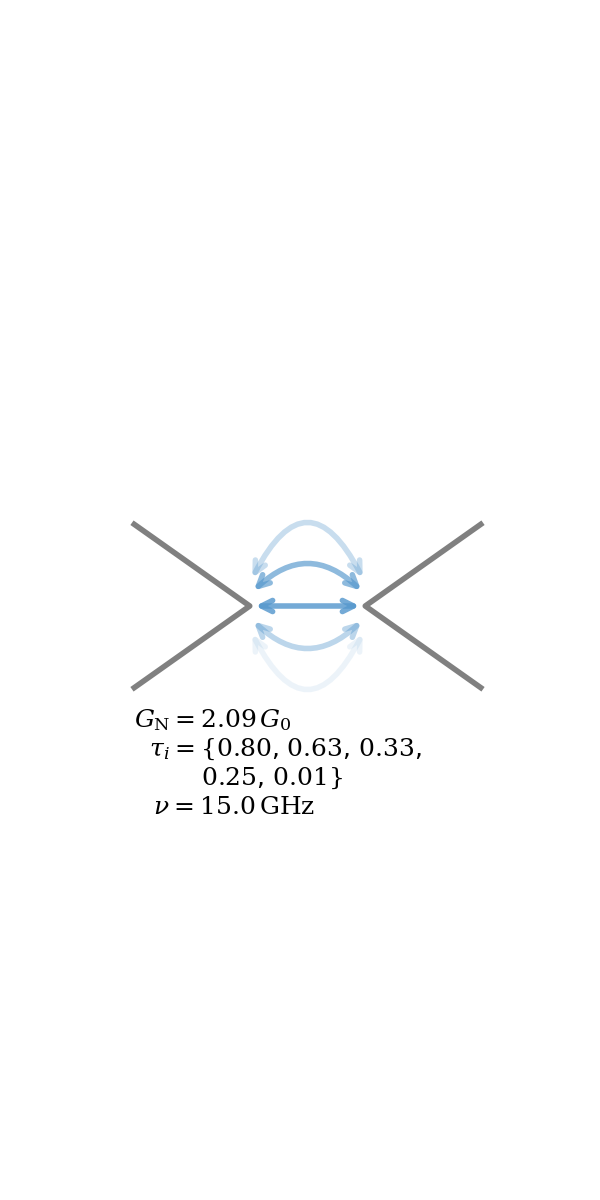

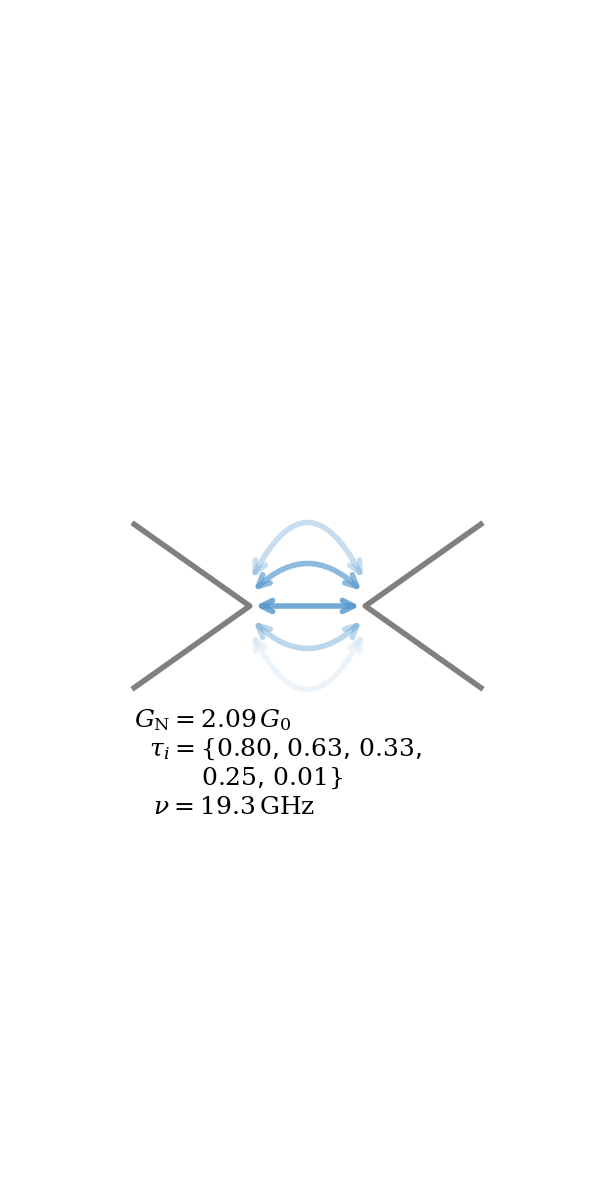

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def seeblau(alpha: float = 1.0):
    return np.array([86.743, 152.566, 205.880, 256 * alpha]) / 256


def center_highest(values):
    sorted_vals = sorted(values, reverse=True)
    center_sorted = []

    for i, val in enumerate(sorted_vals):
        # Alternate insertion left and right around center
        if i == 0:
            center_sorted.insert(len(center_sorted) // 2, val)  # max in center
        elif i % 2 == 1:
            center_sorted.insert(0, val)  # left
        else:
            center_sorted.append(val)  # right

    return center_sorted


G = 2.09  # G_0
pin_code_unsorted = [0.8, 0.63, 0.33, 0.25, 0.01]
nu = [None, 7.8, 15.0, 19.3]

pin_code = pin_code_unsorted.copy()
# pin_code.pop(-1)
pin_code = center_highest(pin_code)

for n in nu:
    fig, ax = plt.subplots(dpi=100, figsize=(3, 6))

    plt.plot(
        [0, 0.5, 0], [-np.sqrt(2) / 4, 0, np.sqrt(2) / 4], color="grey", linewidth=2
    )
    plt.plot(
        [1.5, 1, 1.5], [-np.sqrt(2) / 4, 0, np.sqrt(2) / 4], color="grey", linewidth=2
    )

    for i, pin in enumerate(pin_code):
        rad = (-len(pin_code) / 2 + i + 0.5) * 0.5
        color = seeblau(pin * 0.9 + 0.1)
        arrow = patches.FancyArrowPatch(
            (0.5, -rad / 10),
            (1, -rad / 10),
            connectionstyle=f"arc3,rad={rad}",
            arrowstyle="<->",
            mutation_scale=10,
            color=color,
            linewidth=2,
        )
        ax.add_patch(arrow)

    # Formatting
    # ax.set_xlim(-2, 3)
    ax.set_ylim(-2, 2)
    ax.set_aspect("equal")
    ax.axis("off")
    string = ""
    if G is not None:
        string += r"$G_\mathrm{N}=$" + f"${G:.02f}$" + r"$\,G_0$" + "\n"
    string += r"  $\tau_i = \{$"
    for i, tau in enumerate(pin_code_unsorted):
        string += rf"${tau:.2f}$"
        string += ", "
        if i == len(pin_code_unsorted) - 1:
            break
        if (i + 1) % 3 == 0:
            string += "\n" + r"        $\,$"

    string = string[:-2] + r"$\}$" + "\n"
    if n is not None:
        string += r"  $\,\nu = $" + f"${n:.1f}$" + r"$\,\mathrm{GHz}$"

    plt.annotate(
        string,
        xy=(0, 0),
        xytext=(0, -0.9),
    )
    # plt.tight_layout()
    # plt.show()
    if n is not None:
        plt.savefig(
            f"labels/label_AC_{n}.png",
            dpi=600,
            transparent=True,
            facecolor="none",
            edgecolor="none",
        )
    else:
        plt.savefig(
            f"labels/label_AC.png",
            dpi=600,
            transparent=True,
            facecolor="none",
            edgecolor="none",
        )

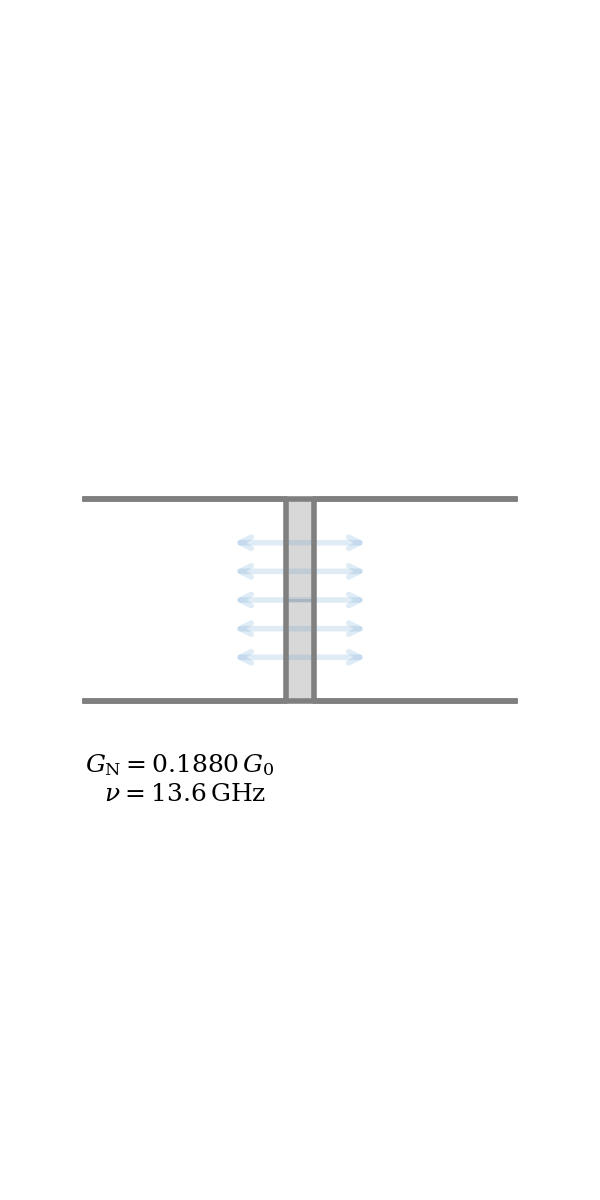

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

G = 0.188  # G_0
pin_code_unsorted = [
    0.1,
    0.1,
    0.1,
    0.1,
    0.1,
]
nu = 13.6

pin_code = pin_code_unsorted.copy()
# pin_code.pop(-1)
pin_code = center_highest(pin_code)

fig, ax = plt.subplots(dpi=100, figsize=(3, 6))

plt.plot(
    [0, 0.7, 0.7, 0],
    [
        -np.sqrt(2) / 4,
        -np.sqrt(2) / 4,
        np.sqrt(2) / 4,
        np.sqrt(2) / 4,
    ],
    color="grey",
    linewidth=2,
)

plt.plot(
    [0, 1.5],
    [np.sqrt(2) / 4, np.sqrt(2) / 4],
    color="grey",
    linewidth=2,
)
plt.plot(
    [0, 1.5],
    [-np.sqrt(2) / 4, -np.sqrt(2) / 4],
    color="grey",
    linewidth=2,
)
plt.plot(
    [1.5, 0.8, 0.8, 1.5],
    [
        -np.sqrt(2) / 4,
        -np.sqrt(2) / 4,
        np.sqrt(2) / 4,
        np.sqrt(2) / 4,
    ],
    color="grey",
    linewidth=2,
)
plt.fill_between(
    [0.7, 0.8, 0.8, 0.7],
    [
        -np.sqrt(2) / 4,
        -np.sqrt(2) / 4,
        np.sqrt(2) / 4,
        np.sqrt(2) / 4,
    ],
    color="grey",
    alpha=0.3,
)

for i, pin in enumerate(pin_code):
    rad = -len(pin_code) / 2 + i + 0.5
    color = seeblau(pin * 0.9 + 0.1)
    arrow = patches.FancyArrowPatch(
        (0.5, -rad / 10),
        (1, -rad / 10),
        # connectionstyle=f"arc3,rad={rad}",
        arrowstyle="<->",
        mutation_scale=10,
        color=color,
        linewidth=2,
    )
    ax.add_patch(arrow)

# Formatting
# ax.set_xlim(-2, 3)
ax.set_ylim(-2, 2)
ax.set_aspect("equal")
ax.axis("off")
string = ""
if G is not None:
    string += r"$G_\mathrm{N}=$" + f"${G:.04f}$" + r"$\,G_0$" + "\n"

# string += r"  $\tau_i = \{$"
# string += rf"$0.01$" + ", "
# string += rf"$0.01$" + ", "
# string += rf"$0.01$" + ", "
# string += "\n" + r"        $\,$"
# string += rf"$0.01$" + ", "
# string += rf"$0.01$" + ", "
# string += rf"$\dots$" + r"$\}$" + "\n"

if nu is not None:
    string += r"  $\,\nu = $" + f"${nu:.1f}$" + r"$\,\mathrm{GHz}$"

# string = string[:-2] + r"$\}$"

plt.annotate(
    string,
    xy=(0, 0),
    xytext=(0, -0.7),
)
# plt.tight_layout()
# plt.show()
plt.tight_layout()
plt.savefig(
    "labels/label_TB.png",
    dpi=600,
    transparent=True,
    facecolor="none",
    edgecolor="none",
)